In [1]:
import polars as pl
import rustystats as rs

data = pl.read_parquet("./conversion_data.parquet")

In [2]:
# data = data.limit(100_000)

In [3]:
# data.write_parquet("./conversion_data_sample.parquet")

In [4]:
model_ns = rs.glm_dict(
    response="sale_flag",
    terms={"difference_to_market": {"type": "ns"}},
    data=data,
    family="binomial",
).fit()

In [6]:
model_bs = rs.glm_dict(
    response="sale_flag",
    terms={"difference_to_market": {"type": "bs"}},
    data=data,
    family="binomial",
).fit()

In [8]:
model_bs_decreasing = rs.glm_dict(
    response="sale_flag",
    terms={"difference_to_market": {"type": "bs", "monotonicity": "decreasing"}},
    data=data,
    family="binomial",
).fit()

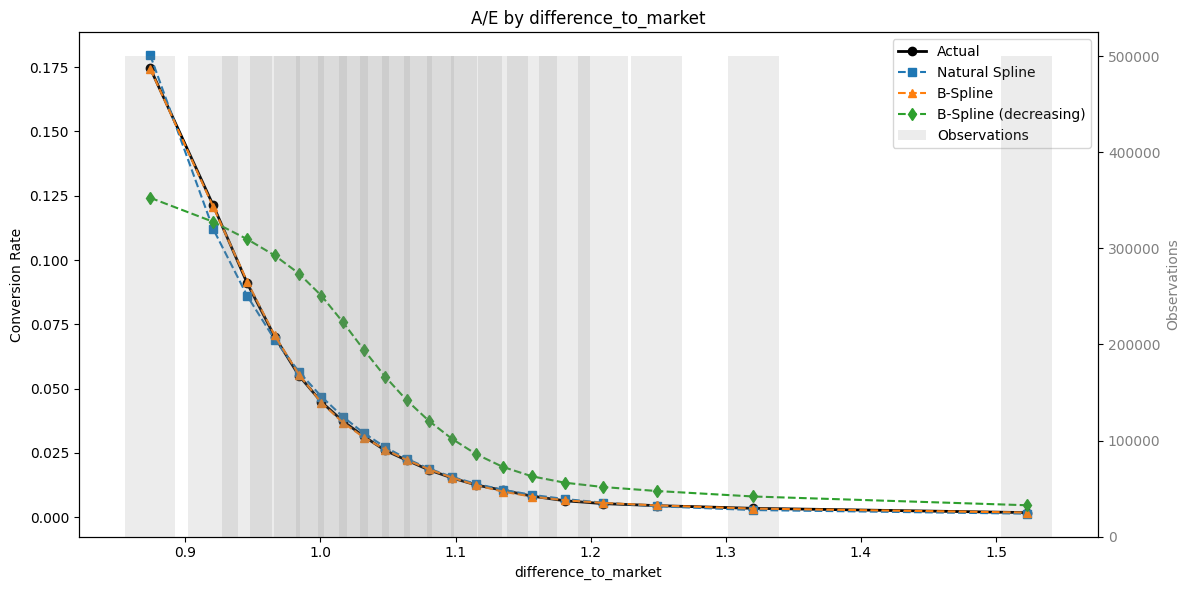

In [10]:
import matplotlib.pyplot as plt

# Generate predictions from all 3 models
pred_ns = model_ns.predict(data)
pred_bs = model_bs.predict(data)
pred_bs_dec = model_bs_decreasing.predict(data)

# Add predictions and bin difference_to_market
plot_data = (
    data.with_columns(
        pl.lit(pred_ns).alias("pred_ns"),
        pl.lit(pred_bs).alias("pred_bs"),
        pl.lit(pred_bs_dec).alias("pred_bs_dec"),
    )
    .with_columns(pl.col("difference_to_market").qcut(20, allow_duplicates=True).alias("bin"))
    .group_by("bin")
    .agg(
        pl.len().alias("obs"),
        pl.col("difference_to_market").mean().alias("mid"),
        pl.col("sale_flag").mean().alias("actual"),
        pl.col("pred_ns").mean().alias("ns"),
        pl.col("pred_bs").mean().alias("bs"),
        pl.col("pred_bs_dec").mean().alias("bs_dec"),
    )
    .sort("mid")
)

mid = plot_data["mid"].to_numpy()
obs = plot_data["obs"].to_numpy()
actual = plot_data["actual"].to_numpy()
ns = plot_data["ns"].to_numpy()
bs = plot_data["bs"].to_numpy()
bs_dec = plot_data["bs_dec"].to_numpy()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars for observation counts (secondary axis)
ax2 = ax1.twinx()
ax2.bar(mid, obs, width=(mid[1] - mid[0]) * 0.8, alpha=0.15, color="grey", label="Observations")
ax2.set_ylabel("Observations", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")

# Lines for actual and predictions
ax1.plot(mid, actual, "o-", color="black", linewidth=2, label="Actual")
ax1.plot(mid, ns, "s--", color="tab:blue", linewidth=1.5, label="Natural Spline")
ax1.plot(mid, bs, "^--", color="tab:orange", linewidth=1.5, label="B-Spline")
ax1.plot(mid, bs_dec, "d--", color="tab:green", linewidth=1.5, label="B-Spline (decreasing)")
ax1.set_xlabel("difference_to_market")
ax1.set_ylabel("Conversion Rate")
ax1.set_title("A/E by difference_to_market")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()